In [72]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud


In [73]:
# Download NLTK Stopwords (Run only once)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Bala
[nltk_data]     Sai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [74]:
# Load Dataset

df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [75]:
# Remove unnecessary columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Display first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [76]:
# Dataset Information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['label'].value_counts())

Shape of Dataset: (5572, 2)

Column Names:
Index(['label', 'message'], dtype='str')

Missing Values:
label      0
message    0
dtype: int64

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [77]:
# Calculate Percentage

percentage = df['label'].value_counts(normalize=True) * 100
print(percentage)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


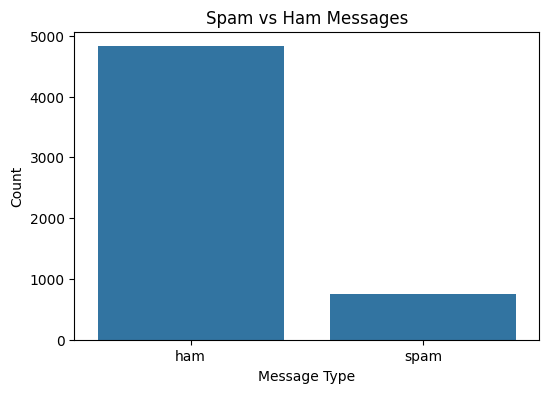

In [78]:
# Class Distribution Chart
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.savefig("outputs/spam_vs_ham.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

The dataset contains 5,572 SMS messages.

Ham (legitimate) messages are much higher than spam messages.

This indicates that the dataset is imbalanced, which is common in real-world spam detection problems.


In [79]:
# Text Preprocessing

stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
df["clean_message"] = df["message"].apply(preprocess)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## TF-IDF Vectorization

TF-IDF (Term Frequency - Inverse Document Frequency) converts text into numerical features.

- Term Frequency (TF): Measures how frequently a word appears in a message.
- Inverse Document Frequency (IDF): Reduces the importance of common words that appear in many messages.
- TF-IDF helps machine learning models focus on important words for spam detection.


In [80]:
# TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_message"])

y = df["label"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5572, 5000)


In [81]:
# Split Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (4457, 5000)
Testing Data : (1115, 5000)


In [82]:
# Train Multinomial Naive Bayes Model

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [83]:
# Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, pos_label="spam"))
print("Recall   :", recall_score(y_test, y_pred_nb, pos_label="spam"))
print("F1 Score :", f1_score(y_test, y_pred_nb, pos_label="spam"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy : 0.9668161434977578
Precision: 0.9912280701754386
Recall   : 0.7583892617449665
F1 Score : 0.8593155893536122

Classification Report:

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



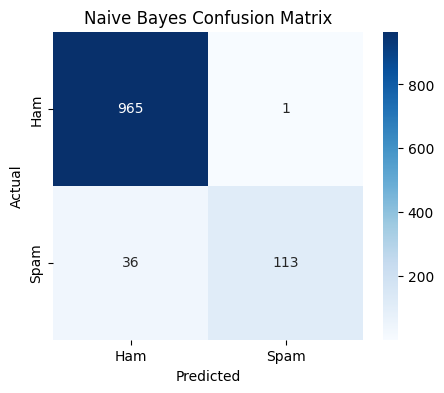

In [84]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("outputs/naive_bayes_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Why Recall is Important in Spam Detection

Recall measures how many actual spam messages are correctly identified.

High recall is important because missing a spam email may expose users to phishing, scams, or malicious content.

Therefore, spam detection systems aim to maximize recall while maintaining good precision.

In [85]:
# Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [86]:
# Logistic Regression Evaluation

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label="spam"))
print("Recall   :", recall_score(y_test, y_pred_lr, pos_label="spam"))
print("F1 Score :", f1_score(y_test, y_pred_lr, pos_label="spam"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9596412556053812
Precision: 0.9905660377358491
Recall   : 0.7046979865771812
F1 Score : 0.8235294117647058

Classification Report:

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.70      0.82       149

    accuracy                           0.96      1115
   macro avg       0.97      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



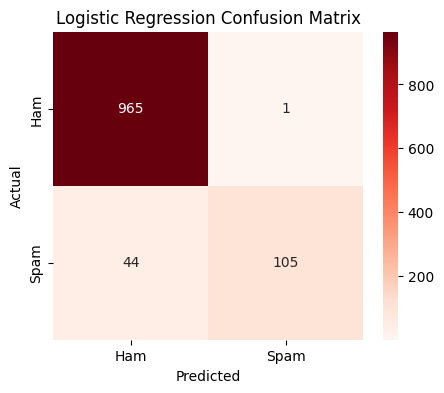

In [87]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("outputs/logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [88]:
# Compare Models

comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ],
    "Precision": [
        precision_score(y_test, y_pred_nb, pos_label="spam"),
        precision_score(y_test, y_pred_lr, pos_label="spam")
    ],
    "Recall": [
        recall_score(y_test, y_pred_nb, pos_label="spam"),
        recall_score(y_test, y_pred_lr, pos_label="spam")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_nb, pos_label="spam"),
        f1_score(y_test, y_pred_lr, pos_label="spam")
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.966816,0.991228,0.758389,0.859316
1,Logistic Regression,0.959641,0.990566,0.704698,0.823529


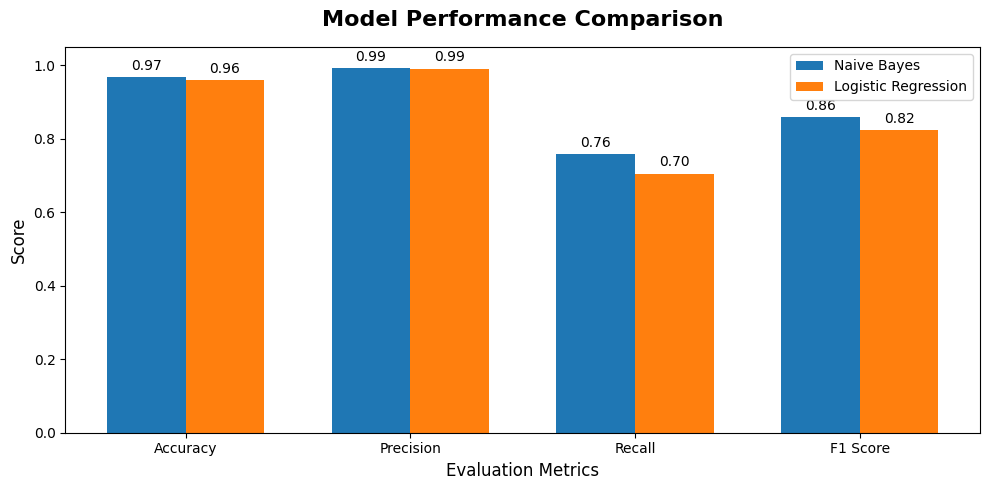

In [89]:
# Professional Model Performance Comparison
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
plt.figure(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.35
nb_scores = comparison.loc[0, metrics].values
lr_scores = comparison.loc[1, metrics].values
bars1 = plt.bar(x - width/2, nb_scores, width, label="Naive Bayes")
bars2 = plt.bar(x + width/2, lr_scores, width, label="Logistic Regression")
plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.2f}",
            ha="center",
            fontsize=10
        )
plt.tight_layout()
plt.savefig(
    "outputs/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

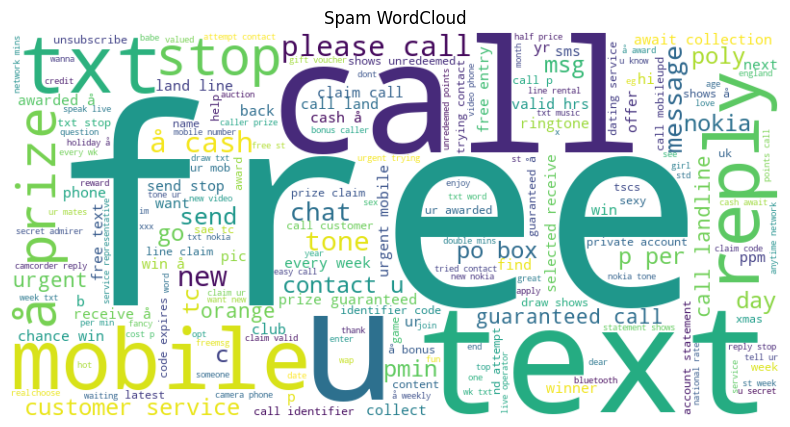

In [90]:
# WordCloud for Spam Messages

from wordcloud import WordCloud

spam_words = " ".join(df[df["label"]=="spam"]["clean_message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Spam WordCloud")
plt.savefig("outputs/spam_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

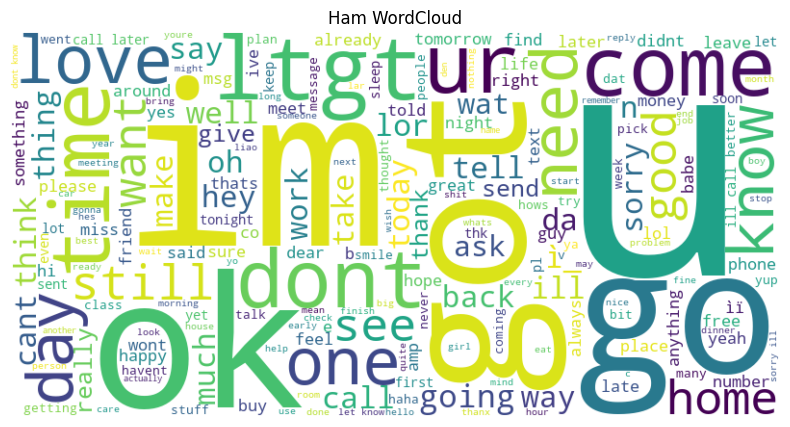

In [91]:
# WordCloud for Ham Messages

ham_words = " ".join(df[df["label"]=="ham"]["clean_message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Ham WordCloud")
plt.savefig("outputs/ham_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

# Conclusion

Two machine learning models were trained and evaluated:

- Multinomial Naive Bayes
- Logistic Regression

The comparison shows the performance of both models using Accuracy, Precision, Recall, and F1 Score.

The model with the higher overall performance is selected as the final spam detection model.